## Recommandation Model Training

#### 1.1 Import Data and Required Packages
##### Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [16]:
import pandas as pd
import torch
import torch.nn.functional as F
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from torch_geometric.utils import to_networkx
import networkx as nx

### import nutrition Dataset

In [17]:
# 1. Load your data
food_df = pd.read_csv('../../data/RecommandationDatasets/nutrients_csvfile.csv')  
print(food_df.head())

                    Food Measure  Grams Calories Protein Fat Sat.Fat Fiber  \
0             Cows' milk   1 qt.    976      660      32  40      36     0   
1              Milk skim   1 qt.    984      360      36   t       t     0   
2             Buttermilk   1 cup    246      127       9   5       4     0   
3  Evaporated, undiluted   1 cup    252      345      16  20      18     0   
4         Fortified milk  6 cups  1,419    1,373      89  42      23   1.4   

  Carbs        Category  
0    48  Dairy products  
1    52  Dairy products  
2    13  Dairy products  
3    24  Dairy products  
4   119  Dairy products  


#### Import User Nutrition Dataset

In [18]:
user_df = pd.read_csv('../../data/preproccedData/Augmented_PreProccedNutrationParameters.csv')
print(user_df.head())

   Age  Gender      Height     Weight  Carbohydrate_Consumption  \
0   24       1  161.609263  48.731866                  1.852525   
1   24       1  159.653670  53.637920                  0.933021   
2   28       0  148.049594  46.770525                  2.773378   
3   24       0  157.719943  54.580482                  1.856103   
4   22       0  149.030373  44.849854                  1.855097   

   Protein_Intake  Fat_Intake  Regularity_of_Meals  Portion_Control  \
0        1.090620    0.916151             0.959783         1.083803   
1        2.175717    0.904236             0.008224         1.065243   
2        3.266809    0.920246             0.000000         2.150421   
3        1.071392    0.915962             0.960743         3.224980   
4        1.116779    0.916990             0.950166         2.145013   

   Hydration  Caloric_Balance  Sugar_Consumption        BMI  DiabetesRisk  \
0   2.043815      2120.952023           1.061643  17.093053     30.774236   
1   1.038885    

#### Define feature and target columns

In [19]:
feature_cols = ['Age', 'Gender', 'Height', 'Weight', 'Regularity_of_Meals',
                'Portion_Control', 'Hydration', 'Caloric_Balance', 
                'Sugar_Consumption', 'BMI', 'DiabetesRisk', 
                 'NutritionRisk']

target_cols = ['Protein_Intake', 'Fat_Intake', 'Carbohydrate_Consumption','NutritionRisk','DiabetesRisk']

#### Scale features

In [20]:
scaler = StandardScaler()
X = scaler.fit_transform(user_df[feature_cols])
y = user_df[target_cols].values

#### Create graph edges based on Age and BMI similarity

In [21]:
similarity_matrix = cosine_similarity(X)
threshold = 0.9
edges = []
for i in range(len(similarity_matrix)):
    for j in range(len(similarity_matrix)):
        if i != j and similarity_matrix[i][j] > threshold:
            edges.append([i, j])

edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

#### Build PyG Data object

In [22]:
x = torch.tensor(X, dtype=torch.float)
y = torch.tensor(y, dtype=torch.float)
data = Data(x=x, edge_index=edge_index, y=y)

#### Visualize the graph

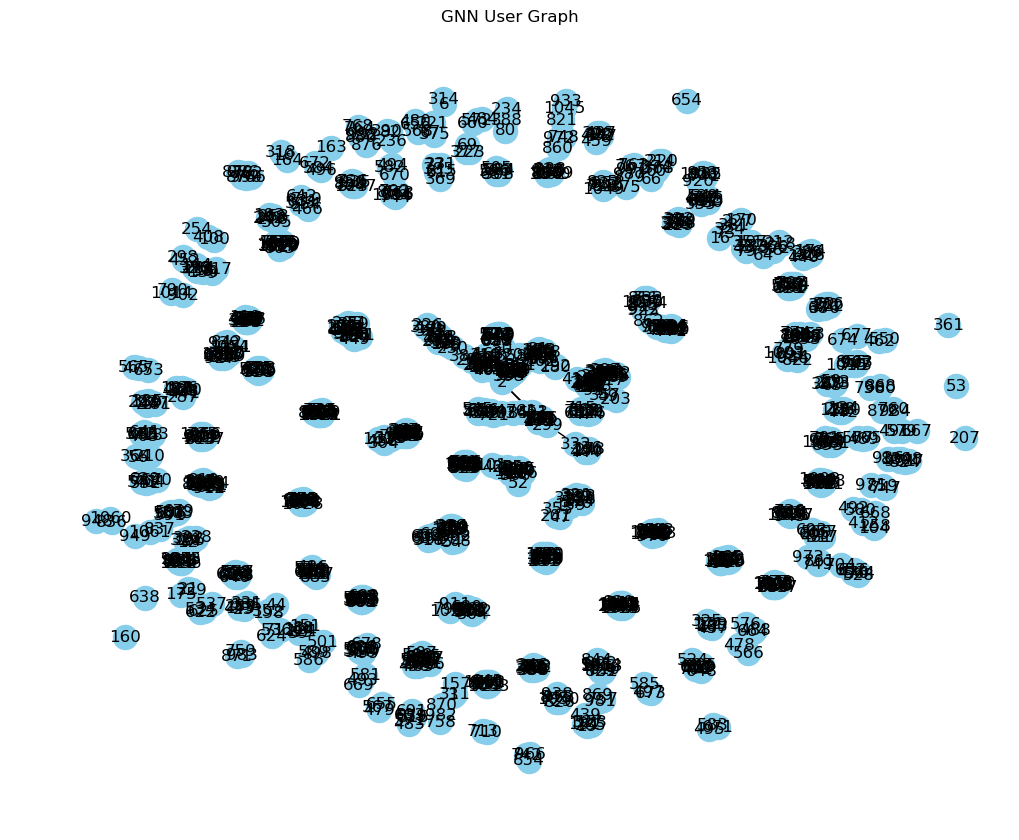

In [23]:
G = to_networkx(data, to_undirected=True)
plt.figure(figsize=(10, 8))
nx.draw(G, with_labels=True, node_size=300, node_color='skyblue')
plt.title("GNN User Graph")
plt.show()

#### Define GCN model

In [24]:
class GCN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, output_dim)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.conv3(x, edge_index)
        return x

### Train the model

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GCN(input_dim=x.shape[1], hidden_dim=64, output_dim=y.shape[1]).to(device)
data = data.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
criterion = torch.nn.MSELoss()

for epoch in range(300):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out, data.y)
    loss.backward()
    optimizer.step()
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 1093.1621
Epoch 20, Loss: 817.1860
Epoch 40, Loss: 309.1583
Epoch 60, Loss: 153.6134
Epoch 80, Loss: 104.7217
Epoch 100, Loss: 83.1378
Epoch 120, Loss: 73.4690
Epoch 140, Loss: 68.5547
Epoch 160, Loss: 65.2441
Epoch 180, Loss: 62.4965
Epoch 200, Loss: 60.2309
Epoch 220, Loss: 58.4142
Epoch 240, Loss: 57.0278
Epoch 260, Loss: 56.0446
Epoch 280, Loss: 55.3645


#### Predict nutrient needs


In [25]:
model.eval()
predictions = model(data.x, data.edge_index).detach().cpu().numpy()
predicted_nutrition = pd.DataFrame(predictions, columns=target_cols)
print("\nPredicted Nutritional Needs:")
print(predicted_nutrition.head())


Predicted Nutritional Needs:
   Protein_Intake  Fat_Intake  Carbohydrate_Consumption  NutritionRisk  \
0        1.020051    0.771293                  1.692945      19.477686   
1        1.822964    1.872710                  3.171750      17.044319   
2        3.470449    1.434688                  3.864768      49.446522   
3        6.437327    1.673316                  6.317731      95.030510   
4        3.759737    1.218332                  3.145469      63.162594   

   DiabetesRisk  
0     13.586945  
1     38.686630  
2     60.796722  
3     97.965889  
4     40.329853  


#### Visualize node embeddings

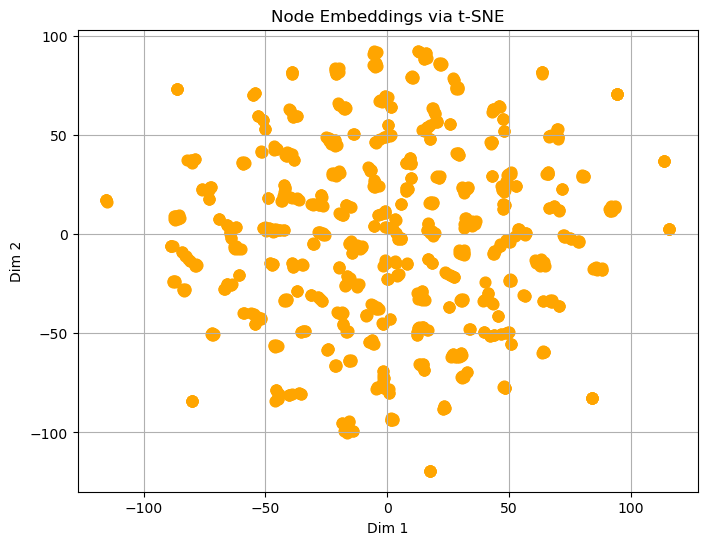

In [26]:
with torch.no_grad():
    embeddings = model.conv1(data.x, data.edge_index).cpu().numpy()

tsne = TSNE(n_components=2, perplexity=5, random_state=42)
emb_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(8, 6))
plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c='orange', s=60)
plt.title("Node Embeddings via t-SNE")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.grid(True)
plt.show()

#### Food recommendation function

In [27]:
def recommend_foods(protein_target, fat_target, carbs_target, top_n=5):
    food_df_clean = food_df.copy()
    food_df_clean[['Protein', 'Fat', 'Carbs']] = food_df_clean[['Protein', 'Fat', 'Carbs']].apply(pd.to_numeric, errors='coerce').fillna(0)

    food_df_clean['score'] = (
        abs(food_df_clean['Protein'] - protein_target) +
        abs(food_df_clean['Fat'] - fat_target) +
        abs(food_df_clean['Carbs'] - carbs_target)
    )

    return food_df_clean.sort_values('score').head(top_n)

 #### Recommend foods for the first user

In [28]:
first_user_pred = predicted_nutrition.iloc[0]
recommended = recommend_foods(
    protein_target=first_user_pred['Protein_Intake'],
    fat_target=first_user_pred['Fat_Intake'],
    carbs_target=first_user_pred['Carbohydrate_Consumption']
)

print("\nRecommended Foods for User 1:")
print(recommended[['Food', 'Measure', 'Grams', 'Calories', 'Protein', 'Fat', 'Carbs', 'Category']])



Recommended Foods for User 1:
                      Food   Measure Grams Calories  Protein  Fat  Carbs  \
118                 Endive     2 oz.    57       10      1.0  0.0    2.0   
123                Lettuce  1/4 head   100       14      1.0  0.0    2.0   
161  Watercress stems, raw     1 cup    50        9      1.0  0.0    1.0   
110              Stalk raw   1 large    40        5      1.0  0.0    1.0   
92               Asparagus  6 spears    96       18      1.0  0.0    3.0   

           Category  
118  Vegetables A-E  
123  Vegetables F-P  
161      Fruits A-F  
110  Vegetables A-E  
92   Vegetables A-E  


#### Meal portion splits (total = 1.0)

In [13]:
meal_ratios = {
    'breakfast': 0.25,
    'lunch': 0.30,
    'dinner': 0.30,
    'snack': 0.15
}

#### Build 7-day meal plan for a user

In [29]:
import random

# 12. Generate a 7-day meal plan
def generate_meal_plan(user_pred, food_df, meals_per_day=['breakfast', 'lunch', 'dinner', 'snack']):
    plan = {}
    # Scale the total predicted intake to split across meals
    daily_targets = {
        'breakfast': 0.25,
        'lunch': 0.35,
        'dinner': 0.30,
        'snack': 0.10
    }

    for day in range(1, 8):
        day_plan = {}
        for meal in meals_per_day:
            ratio = daily_targets[meal]
            protein_target = user_pred['Protein_Intake'] * ratio
            fat_target = user_pred['Fat_Intake'] * ratio
            carbs_target = user_pred['Carbohydrate_Consumption'] * ratio

            recommended_meals = recommend_foods(protein_target, fat_target, carbs_target, top_n=5)

            # Randomly pick one meal from the top recommendations
            chosen = recommended_meals.sample(1).iloc[0]
            day_plan[meal] = {
                'Food': chosen['Food'],
                'Calories': chosen['Calories'],
                'Protein': chosen['Protein'],
                'Fat': chosen['Fat'],
                'Carbs': chosen['Carbs'],
                'Category': chosen.get('Category', 'Unknown')
            }
        plan[f'Day {day}'] = day_plan
    return plan

# Generate meal plan for first user
meal_plan = generate_meal_plan(first_user_pred, food_df)

# Pretty-print the plan
from pprint import pprint
print("\n7-Day Meal Plan for User 1:")
pprint(meal_plan)



7-Day Meal Plan for User 1:
{'Day 1': {'breakfast': {'Calories': '2',
                         'Carbs': 0.0,
                         'Category': 'Vegetables F-P',
                         'Fat': 0.0,
                         'Food': 'Parsley',
                         'Protein': 0.0},
           'dinner': {'Calories': '4',
                      'Carbs': 1.0,
                      'Category': 'Drinks,Alcohol, Beverages',
                      'Fat': 0.0,
                      'Food': 'Tea',
                      'Protein': 0.0},
           'lunch': {'Calories': '4',
                     'Carbs': 1.0,
                     'Category': 'Drinks,Alcohol, Beverages',
                     'Fat': 0.0,
                     'Food': 'Tea',
                     'Protein': 0.0},
           'snack': {'Calories': '250',
                     'Carbs': 0.0,
                     'Category': 'Desserts, sweets',
                     'Fat': 0.0,
                     'Food': 'Ice cream',
                   

#### Generate plan for first user